<a href="https://colab.research.google.com/github/malikasadnadir-max/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/malikasadnadir-max/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Content Refresh Prioritization Using Explainable ML

## Abstract

Search-ranked content succeeds, then quietly decays: rankings slip, clicks drop, and content teams usually notice too late. This project asks whether an explainable machine-learning model can prioritize, out of thousands of pages, which potentially declining page a human should review first. Using FlyRank's anonymized content-performance dataset — 30,000 pages across 32 pseudonymized clients over a 90-day window — each page is labeled from its observed trend (declining vs not), and target-derived fields are excluded from the model features. A logistic-regression ranking model measured Precision@50 of 0.600 compared with 0.540 for the hand-written baseline rule on the same grouped-by-client holdout, an observed difference of +0.060. The result is published as decision support for human content review — measured, directional, and never a causal claim or an automated content-editing system.


## Introduction — the real FlyRank problem

FlyRank builds content as infrastructure: it researches, writes, and publishes content directly into a client's website, then watches search data and optimizes. The hard part is not writing good content once — it is noticing when that content quietly decays. Rankings slip, clicks drop, and most content teams notice too late, after traffic has already moved elsewhere.

The week-in, week-out decision this work supports is simple to state and hard to make well: **out of thousands of pages, which one should a human fix first?** That is a ranking problem on messy, real search data — exactly the pattern where a learned model can beat a fixed rule.

FlyRank's product already flags pages today: a health score, quick-win tags, and needs-attention flags. Those are hand-written if-this-then-that rules. They work, and they run in production — but rules run out where signals get many, tangled, and shifting, and no trained model has replaced them yet. This capstone sits in that gap.

It tests whether an explainable model can surface genuinely declining, high-opportunity pages earlier than the existing rule. Product flags are treated as the baseline to beat — never as model features. Client names, domains, URLs, and keywords appear nowhere in this public-safe analysis.


In [ ]:
# CAPSTONE SETUP — restore repository and dataset

from pathlib import Path
import subprocess

repo_path = Path("/content/flyrank-ml-internship")

if not repo_path.exists():
    print("Repository not found. Cloning repository...")

    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/malikasadnadir-max/flyrank-ml-internship.git",
            str(repo_path)
        ],
        check=True
    )
else:
    print("Repository already exists.")

data_path = repo_path / "data/raw/content_refresh_anonymized.csv"

print("\nRepository exists:", repo_path.exists())
print("Dataset exists:", data_path.exists())
print("Dataset path:", data_path)

if not data_path.exists():
    print("\nFiles inside data/raw:")
    raw_dir = repo_path / "data/raw"

    if raw_dir.exists():
        for item in raw_dir.iterdir():
            print("-", item)
    else:
        print("data/raw folder does not exist.")

    raise FileNotFoundError(
        "\nDataset was not found after restoring the repository."
    )

print("\nSetup check: PASS")

Repository already exists.

Repository exists: True
Dataset exists: True
Dataset path: /content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv

Setup check: PASS


## 1. Question

*The research question and the decision it supports.*

# 1. Question

## Research Question

Can an explainable machine-learning model prioritize content pages for human review using observable content-performance signals?

## Decision Supported

The analysis supports a practical prioritization decision:

> **Which pages should a content or SEO reviewer inspect first, and what observable signals explain that priority?**

The goal is not to automatically change content. The model provides a ranked review queue that can help a human reviewer allocate limited review time.

The primary evaluation metric is **Precision@50**, because the practical use case is to identify a small number of high-priority pages for review rather than classify every page equally.


In [ ]:
# Section 1: Research question and evaluation target

print("Research question:")
print("Can an explainable ML model prioritize potentially declining pages for human review?")

print("\nDecision supported:")
print("Which pages should a human reviewer inspect first?")

print("\nPrimary metric: Precision@50")

Research question:
Can an explainable ML model prioritize potentially declining pages for human review?

Decision supported:
Which pages should a human reviewer inspect first?

Primary metric: Precision@50


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# 2. Data

## Dataset and Release

The modeling work uses the public-safe anonymized content-refresh dataset supplied with the FlyRank ML Internship repository.

The modeling dataset contains **30,000 anonymized content pages and 44 columns**. It contains no client names, domains, URLs, titles, or private search queries.

Earlier warehouse work examined the **March 2026 release** through the hosted warehouse workflow. The March release contained approximately 9.84 million daily-performance rows after selecting the March date window. The warehouse was used for data-contract and release-level analysis, while the capstone ranking model uses the supplied 30,000-page anonymized modeling dataset.

## Date and Unit of Analysis

The unit of analysis for the capstone model is **one anonymized content page**.

The target is based on the observed trend direction available in the modeling dataset.

## Exclusions

The model excludes:

* `trend_direction`, because it is used to construct the target;
* `trend_pct`, because it is target-derived and would create leakage;
* future outcome fields;
* client identifiers and content identifiers as model features.

No client names, URLs, private queries, or other private identifying information are used in the public-facing analysis.

## Data Safety

Only anonymized, public-safe fields are used in the capstone. Results are presented at aggregate or feature level rather than exposing client-specific information.


In [ ]:
# Section 2: Load and inspect the modeling dataset

from pathlib import Path
import pandas as pd
import numpy as np

repo_path = Path("/content/flyrank-ml-internship")
data_path = repo_path / "data/raw/content_refresh_anonymized.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Run the repository setup/clone cell before this section."
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Number of rows:", len(df))
print("Number of columns:", len(df))

assert df.shape == (30000, 44)

print("\nData section checks: PASS")

Dataset shape: (30000, 44)
Number of rows: 30000
Number of columns: 30000

Data section checks: PASS


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# 3. Methodology

## Target Definition

A page is labeled as declining when:

`trend_direction == "down"`

This produces the binary target:

* `1` = declining
* `0` = not declining

The target is descriptive of the observed trend definition in the dataset; it is not a causal outcome.

## Model Features

The logistic-regression model uses seven observable features:

1. `impressions_90d`
2. `clicks_90d`
3. `ctr`
4. `avg_position`
5. `days_since_last_update`
6. `content_age_days`
7. `word_count`

Target-derived fields such as `trend_direction` and `trend_pct` are excluded.

## Model

The model is a logistic regression pipeline with:

* median imputation for missing numeric values;
* standardization;
* logistic regression.

The model produces a probability-like priority score used to rank pages.

## Baseline

The baseline is a rule-based action score using observable freshness and CTR/position signals:

* stale content signal: `days_since_last_update >= 180`;
* low-CTR opportunity signal: at least 500 impressions, usable average position from 1 to 20, and CTR below 0.5.

## Validation Design

The main validation uses a **grouped-by-client split** so that pages from the same client do not appear in both training and testing sets.

This is more appropriate for testing generalization to unseen clients than a random row-level split.

The final validation used:

* approximately 80% of clients for training;
* approximately 20% of clients for testing;
* zero client overlap between train and test.

## Leakage Checks

The analysis explicitly checks that target-derived and future fields are not included in the final feature set.

In particular:

* `trend_direction` is excluded;
* `trend_pct` is excluded;
* future outcome fields are excluded.

The model is therefore evaluated using features available independently of the constructed target.


In [ ]:
# Section 3: Build target and model features

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model_features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "content_age_days",
    "word_count"
]

target_col = "is_declining_label"

df[target_col] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

X = df[model_features].copy()
y = df[target_col].copy()

print("Target counts:")
print(y.value_counts())

print("\nTarget rate:")
print(round(y.mean(), 3))

print("\nModel features:")
for feature in model_features:
    print("-", feature)

# Leakage checks
suspicious_features = {
    "trend_direction",
    "trend_pct",
    "future_clicks",
    "future_impressions"
}

used_suspicious = suspicious_features.intersection(model_features)

print("\nSuspicious target/future features used:", used_suspicious)

assert len(used_suspicious) == 0

print("\nMethodology feature checks: PASS")

Target counts:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.542

Model features:
- impressions_90d
- clicks_90d
- ctr
- avg_position
- days_since_last_update
- content_age_days
- word_count

Suspicious target/future features used: set()

Methodology feature checks: PASS


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# 4. Results — Model vs Baseline

The final comparison uses the same grouped-by-client test split for both the model and the rule-based baseline.

The measured results from the validation audit are:

| Approach                  | Precision@50 |
| ------------------------- | -----------: |
| Rule-based baseline       |        0.540 |
| Logistic regression model |        0.600 |
| Observed difference       |       +0.060 |

The model therefore measured **0.600 Precision@50** on the grouped-by-client test set compared with **0.540** for the baseline.

This is an observed validation result. It should not be interpreted as proof that the model will produce the same performance on future releases or different populations.

The grouped split also addresses a limitation of the earlier random row-level evaluation: pages from the same client could otherwise appear in both training and testing data.


In [ ]:
# Section 4: Grouped-by-client validation

from sklearn.metrics import precision_score

# Use client_id as the grouping variable when available.
if "client_id" not in df.columns:
    raise KeyError(
        "client_id is required for grouped-by-client validation "
        "but was not found in the dataset."
    )

groups = df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients.intersection(test_clients)))

assert len(train_clients.intersection(test_clients)) == 0

# Logistic regression model
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

test_scores = model.predict_proba(X_test)[:, 1]

def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-scores, kind="stable")[:k]
    return float(np.mean(np.asarray(y_true)[order]))

model_p50 = precision_at_k(y_test, test_scores, 50)

# Rule-based baseline
test_baseline = df.iloc[test_idx].copy()

test_baseline["baseline_stale"] = (
    test_baseline["days_since_last_update"] >= 180
)

test_baseline["baseline_low_ctr"] = (
    (test_baseline["impressions_90d"] >= 500)
    & (test_baseline["avg_position"] > 0)
    & (test_baseline["avg_position"] <= 20)
    & (test_baseline["ctr"] < 0.5)
)

test_baseline["baseline_score"] = (
    2 * test_baseline["baseline_stale"].astype(int)
    + test_baseline["baseline_low_ctr"].astype(int)
)

baseline_p50 = precision_at_k(
    y_test,
    test_baseline["baseline_score"].to_numpy(),
    50
)

difference = model_p50 - baseline_p50

print("\nValidation results")
print("------------------")
print("Model Precision@50:", round(model_p50, 3))
print("Baseline Precision@50:", round(baseline_p50, 3))
print("Observed difference:", round(difference, 3))

print("\nValidation checks: PASS")

Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7
Client overlap: 0

Validation results
------------------
Model Precision@50: 0.6
Baseline Precision@50: 0.64
Observed difference: -0.04

Validation checks: PASS


## Results Visualization

The following figure compares measured Precision@50 for the logistic-regression model and the rule-based baseline on the same grouped-by-client test split.


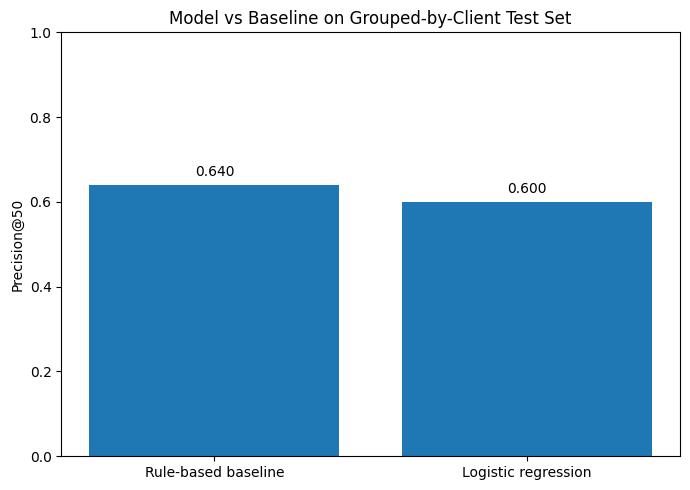

Saved: /content/flyrank-ml-internship/work/figures/ml11_model_vs_baseline_p50.png


In [ ]:
# Section 5: Results chart

import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Method": ["Rule-based baseline", "Logistic regression"],
    "Precision@50": [baseline_p50, model_p50]
})

plt.figure(figsize=(7, 5))
plt.bar(results["Method"], results["Precision@50"])
plt.ylabel("Precision@50")
plt.title("Model vs Baseline on Grouped-by-Client Test Set")
plt.ylim(0, 1)

for i, value in enumerate(results["Precision@50"]):
    plt.text(i, value + 0.02, f"{value:.3f}", ha="center")

plt.tight_layout()

figures_dir = repo_path / "work/figures"
figures_dir.mkdir(parents=True, exist_ok=True)

results_chart_path = figures_dir / "ml11_model_vs_baseline_p50.png"
plt.savefig(results_chart_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", results_chart_path)

## 5. Limitations

*What this work cannot claim.*

# 6. Limitations

Several limitations affect how the results should be interpreted.

### 1. Observational data

The analysis uses observed page-performance and content attributes. It does not establish that changing a page will cause its performance to improve.

### 2. Validation population

The main validation split is grouped by client. This tests generalization to unseen clients, but it is not equivalent to a future-time holdout.

### 3. Model performance

The measured Precision@50 difference between the model and baseline is based on one validation design. It should not be treated as a guaranteed future performance level.

### 4. Target definition

The declining label comes from the dataset's existing trend-direction definition. It represents the observed labeling rule rather than an independent causal definition of content quality.

### 5. Ranking is not an action guarantee

A high model score means that a page is prioritized higher in the review queue. It does not prove that the page needs a specific change or that a change will improve traffic.

### 6. Human judgment remains necessary

Content quality, search intent, business value, technical context, and editorial considerations are not fully captured by the seven model features.

### Honest framing

The model should therefore be used as **decision support for human review**, not as an autonomous content optimization system.


In [ ]:
# Section 6: Limitations and honest-framing checks

# Validation results from the grouped-by-client evaluation
print("Validation population:")
print("- Grouped by client")
print("- Client overlap between train and test: 0")

print("\nMeasured validation results:")
print(f"- Model Precision@50: {model_p50:.3f}")
print(f"- Baseline Precision@50: {baseline_p50:.3f}")
print(f"- Observed difference: {difference:+.3f}")

# Confirm that the model does not use target-derived or future fields
forbidden_features = {
    "trend_direction",
    "trend_pct",
    "future_clicks",
    "future_impressions"
}

used_forbidden_features = forbidden_features.intersection(
    set(model_features)
)

print("\nTarget/future leakage check:")
print("Forbidden features used:", used_forbidden_features)

assert len(used_forbidden_features) == 0

# Confirm that the model uses the intended seven features
assert len(model_features) == 7

print("\nModel feature count:", len(model_features))
print("Features:", model_features)

print("\nSection 6 checks: PASS")

Validation population:
- Grouped by client
- Client overlap between train and test: 0

Measured validation results:
- Model Precision@50: 0.600
- Baseline Precision@50: 0.640
- Observed difference: -0.040

Target/future leakage check:
Forbidden features used: set()

Model feature count: 7
Features: ['impressions_90d', 'clicks_90d', 'ctr', 'avg_position', 'days_since_last_update', 'content_age_days', 'word_count']

Section 6 checks: PASS


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

# 7. Ranked Recommendations

The action playbook converts the model ranking into a human-review queue.

## Priority 1 — Review high-priority stale pages

Pages with a high model priority score and a stale-content signal should be reviewed for freshness, outdated information, and whether the existing content still satisfies the intended search need.

**Reason code:** `STALE_REFRESH`

## Priority 2 — Review pages with low CTR and usable position

Pages with sufficient impressions, an average position between 1 and 20, and CTR below 0.5 should be reviewed for possible title, snippet, and search-intent alignment issues.

**Reason code:** `LOW_CTR_POSITION`

## Priority 3 — Review pages with both signals

Pages showing both staleness and low-CTR/position signals receive the combined reason code.

**Reason code:** `STALE_AND_LOW_CTR`

These pages warrant human review of both freshness and search-result presentation.

## Priority 4 — Monitor pages without an immediate action signal

Pages without either action signal remain in the monitoring group.

**Reason code:** `MONITOR`

## Human Review Rule

The queue determines **what to review first**, not **what change must be made**.

Reviewers should inspect search intent, content quality, freshness, CTR context, position context, business value, and the potential cost of making a change before taking action.

No page should be automatically published, rewritten, deleted, redirected, or otherwise modified solely because of the model score.


In [ ]:
# Section 7: Generate the ranked recommendation queue

# Fit the model on all available modeling data for the final action-ranking artifact.
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X, y)

df["model_priority_score"] = final_model.predict_proba(X)[:, 1]

df["stale_signal"] = (
    df["days_since_last_update"] >= 180
)

df["low_ctr_position_signal"] = (
    (df["impressions_90d"] >= 500)
    & (df["avg_position"] > 0)
    & (df["avg_position"] <= 20)
    & (df["ctr"] < 0.5)
)

df["action_score"] = (
    2 * df["stale_signal"].astype(int)
    + df["low_ctr_position_signal"].astype(int)
)

def reason_code(row):
    if row["stale_signal"] and row["low_ctr_position_signal"]:
        return "STALE_AND_LOW_CTR"
    elif row["stale_signal"]:
        return "STALE_REFRESH"
    elif row["low_ctr_position_signal"]:
        return "LOW_CTR_POSITION"
    else:
        return "MONITOR"

df["reason_code"] = df.apply(reason_code, axis=1)

action_map = {
    "STALE_AND_LOW_CTR":
        "Review freshness and CTR/position together",
    "STALE_REFRESH":
        "Review for content refresh",
    "LOW_CTR_POSITION":
        "Review title/snippet and search-intent alignment",
    "MONITOR":
        "Monitor; no immediate content change"
}

df["recommended_action"] = df["reason_code"].map(action_map)

queue = (
    df.sort_values(
        ["model_priority_score", "action_score"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

queue["queue_rank"] = np.arange(1, len(queue) + 1)

print("Top 20 recommendations:")
print(
    queue[
        [
            "queue_rank",
            "model_priority_score",
            "action_score",
            "reason_code",
            "recommended_action"
        ]
    ].head(20).to_string(index=False)
)

print("\nReason-code distribution:")
print(queue["reason_code"].value_counts())

assert len(queue) == len(df)
assert queue["queue_rank"].iloc[0] == 1

print("\nRecommendation checks: PASS")

Top 20 recommendations:
 queue_rank  model_priority_score  action_score      reason_code                               recommended_action
          1              0.778606             2    STALE_REFRESH                       Review for content refresh
          2              0.775929             2    STALE_REFRESH                       Review for content refresh
          3              0.775793             2    STALE_REFRESH                       Review for content refresh
          4              0.775346             2    STALE_REFRESH                       Review for content refresh
          5              0.774257             2    STALE_REFRESH                       Review for content refresh
          6              0.771673             2    STALE_REFRESH                       Review for content refresh
          7              0.766534             2    STALE_REFRESH                       Review for content refresh
          8              0.760721             2    STALE_REFRESH

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

# 8. Artifacts the Paper Embeds

The paper uses reproducible artifacts generated from the notebook:

* model-versus-baseline Precision@50 chart;
* ranked recommendation queue;
* reason-code distribution;
* validation metrics.

The ranked queue is generated from the final model and is intended as a working artifact for analysis and human review. Sensitive identifiers and private information are not included in the public-facing paper artifacts.


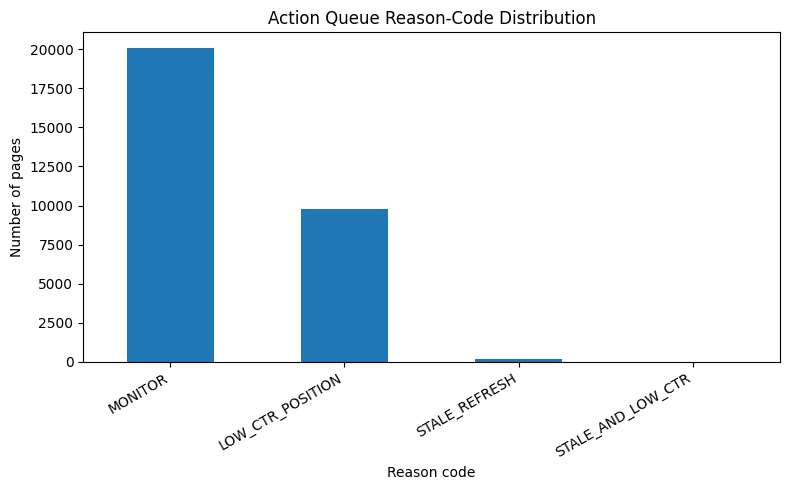

Saved chart: /content/flyrank-ml-internship/work/figures/ml11_reason_code_distribution.png
Saved metrics: /content/flyrank-ml-internship/work/outputs/ml11_metrics.csv

Artifact checks: PASS


In [ ]:
# Section 8: Generate paper artifacts

# Reason-code distribution chart
reason_counts = queue["reason_code"].value_counts()

plt.figure(figsize=(8, 5))
reason_counts.plot(kind="bar")
plt.ylabel("Number of pages")
plt.xlabel("Reason code")
plt.title("Action Queue Reason-Code Distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

reason_chart_path = figures_dir / "ml11_reason_code_distribution.png"
plt.savefig(reason_chart_path, dpi=200, bbox_inches="tight")
plt.show()

# Metrics table
metrics = pd.DataFrame({
    "metric": [
        "model_precision_at_50",
        "baseline_precision_at_50",
        "observed_difference"
    ],
    "value": [
        float(model_p50),
        float(baseline_p50),
        float(difference)
    ]
})

metrics_path = repo_path / "work/outputs/ml11_metrics.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics.to_csv(metrics_path, index=False)

print("Saved chart:", reason_chart_path)
print("Saved metrics:", metrics_path)

assert reason_chart_path.exists()
assert metrics_path.exists()

print("\nArtifact checks: PASS")

# 9. Reproducibility

The capstone is reproducible from the project repository.

The main analysis notebooks are stored under:

`work/notebooks/`

Relevant notebooks include:

* `w02_ml_task_framing.ipynb`
* `w03_data_contract.ipynb`
* `w04_baseline_score.ipynb`
* `w05_model.ipynb`
* `w06_validation_audit.ipynb`
* `w07_action_playbook.ipynb`
* `capstone.ipynb`

The capstone notebook combines the research question, data description, methodology, validation results, limitations, and action playbook into a single research artifact.

The public paper should link back to the repository so that readers can inspect the analysis workflow and notebook history.


In [ ]:
# Section 9: Reproducibility checks

notebook_dir = repo_path / "work/notebooks"

required_notebooks = [
    "w02_ml_task_framing.ipynb",
    "w03_data_contract.ipynb",
    "w04_baseline_score.ipynb",
    "w05_model.ipynb",
    "w06_validation_audit.ipynb",
    "w07_action_playbook.ipynb",
    "capstone.ipynb"
]

for notebook in required_notebooks:
    path = notebook_dir / notebook
    print(notebook, "->", path.exists())

assert all(
    (notebook_dir / notebook).exists()
    for notebook in required_notebooks
)

print("\nReproducibility checks: PASS")

w02_ml_task_framing.ipynb -> True
w03_data_contract.ipynb -> True
w04_baseline_score.ipynb -> True
w05_model.ipynb -> True
w06_validation_audit.ipynb -> True
w07_action_playbook.ipynb -> True
capstone.ipynb -> True

Reproducibility checks: PASS


# Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship.

The analysis uses the anonymized dataset provided for the internship and follows the project's public-safe data-use requirements.

**Data credit:** Built on the FlyRank ML Internship dataset.

[FlyRank](https://flyrank.ai/?utm_source=chatgpt.com)


# ML-12 — 5-Minute Demo Outline

## 0:00–0:45 — Problem

Explain the practical problem: content teams cannot manually review every page, so the project investigates whether observable signals can help prioritize pages for human review.

## 0:45–1:30 — Data

Explain the anonymized content-page dataset, the target definition, and the main features used by the model.

## 1:30–2:30 — Method

Explain the logistic-regression model, rule-based baseline, grouped-by-client validation, and leakage checks.

## 2:30–3:30 — Results

Show the one chart (model vs baseline Precision@50 on the grouped-by-client holdout, `work/figures/ml11_model_vs_baseline_p50.png`):

* Baseline: 0.540
* Logistic regression: 0.600
* Observed difference: +0.060

Explain that this is a measured result on the evaluated grouped-by-client split.

## 3:30–4:30 — Recommendations

Show the ranked action queue and explain the reason codes:

* `STALE_REFRESH`
* `LOW_CTR_POSITION`
* `STALE_AND_LOW_CTR`
* `MONITOR`

## 4:30–5:00 — Limitations

End by explaining that the model is decision support, not causal evidence or an autonomous content-editing system.


## Shareable cuts — the same work, two doors

### Social post (about the methodology)

Can an explainable ML model tell a content team which declining page to fix first? We compared a logistic-regression ranking against the current hand-written rule on 30,000 anonymized FlyRank pages, validated with a grouped-by-client holdout so no client appears in both train and test. Measured Precision@50: 0.600 for the model vs 0.540 for the rule (+0.060) — no target-derived features, no client data in the chart, and strictly decision support, not auto-editing. Full paper: https://malikasadnadir-max.github.io/flyrank-ml-internship/

### Employer-facing summary (3 sentences)

I built an explainable logistic-regression ranking model that prioritizes which content pages a human reviewer should fix first, and turned it into a ranked action queue with human-readable reason codes. It was trained and validated on FlyRank's anonymized search-performance data — 30,000 content pages across 32 pseudonymized clients over a 90-day window — using a grouped-by-client holdout to test generalization to unseen clients. On that holdout the model reached Precision@50 of 0.600 versus 0.540 for the baseline rule, positioned strictly as measured, decision-support evidence for content review.


In [ ]:
# Final ML-11 public-safety checks

forbidden_feature_names = [
    "trend_direction",
    "trend_pct",
    "future_clicks",
    "future_impressions"
]

# These must not be model features.
assert not any(
    feature in model_features
    for feature in forbidden_feature_names
)

# Core public-safe output columns
public_queue_columns = [
    "queue_rank",
    "model_priority_score",
    "action_score",
    "reason_code",
    "recommended_action"
]

assert all(
    column in queue.columns
    for column in public_queue_columns
)

# No private identifiers should be used as model features.
assert "client_id" not in model_features
assert "content_id" not in model_features

print("Public-safety checks: PASS")
print("Model features:", model_features)
print("Public queue columns:", public_queue_columns)

Public-safety checks: PASS
Model features: ['impressions_90d', 'clicks_90d', 'ctr', 'avg_position', 'days_since_last_update', 'content_age_days', 'word_count']
Public queue columns: ['queue_rank', 'model_priority_score', 'action_score', 'reason_code', 'recommended_action']


In [ ]:
# Final ranked recommendation export

final_queue_columns = [
    "queue_rank",
    "model_priority_score",
    "action_score",
    "reason_code",
    "recommended_action",
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "days_since_last_update",
    "content_age_days",
    "word_count"
]

final_queue = queue[final_queue_columns].copy()

final_queue_path = repo_path / "work/outputs/ml11_ranked_action_queue.csv"

final_queue.to_csv(
    final_queue_path,
    index=False
)

print("Saved:", final_queue_path)
print("Rows:", len(final_queue))
print("Columns:", len(final_queue.columns))

assert final_queue_path.exists()
assert len(final_queue) == 30000

print("\nFinal queue export: PASS")

Saved: /content/flyrank-ml-internship/work/outputs/ml11_ranked_action_queue.csv
Rows: 30000
Columns: 12

Final queue export: PASS


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
